In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

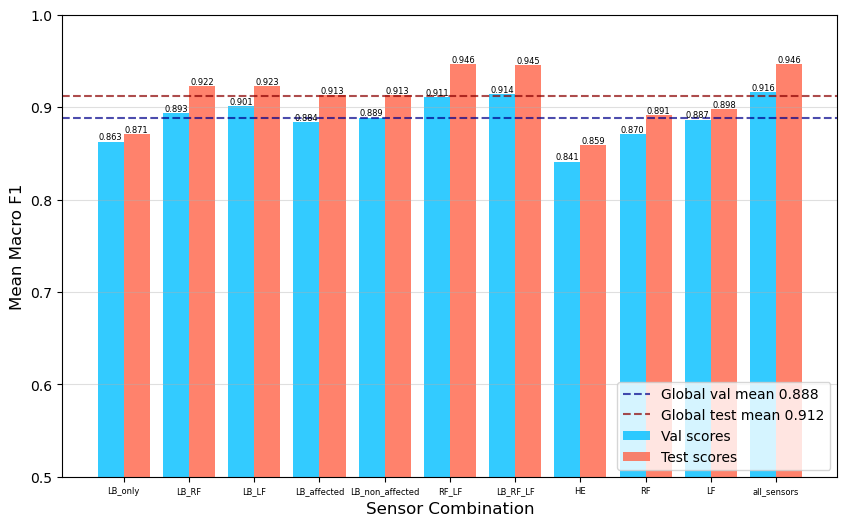

In [48]:
results = pd.read_csv('results/model_scores.csv')

val_scores = results['f1_val']
test_scores = results['f1_test']
model_names = results['model'].str[11:]

barwidth = 0.4
br1 = np.arange(len(val_scores))
br2 = [x + barwidth for x in br1]

fig = plt.figure(figsize=(10,6))

bar_val = plt.bar(br1, val_scores, width=barwidth, color='deepskyblue', alpha=0.8, label='Val scores')
bar_test = plt.bar(br2, test_scores, width=barwidth, color='tomato', alpha=0.8, label='Test scores')
plt.bar_label(bar_val, fmt='%.3f', fontsize=6)
plt.bar_label(bar_test, fmt='%.3f', fontsize=6)

global_mean_val = val_scores.mean()
global_mean_test = test_scores.mean()

plt.axhline(global_mean_val, color='darkblue', linestyle='--', alpha=0.7, label=f'Global val mean {global_mean_val:.3f}')
plt.axhline(global_mean_test, color='darkred', linestyle='--', alpha=0.7, label=f'Global test mean {global_mean_test:.3f}')

plt.ylim(0.5, 1)
plt.ylabel('Mean Macro F1', fontsize=12)
plt.xlabel('Sensor Combination', fontsize=12) 
plt.xticks([r + barwidth / 2 for r in range(len(val_scores))], model_names, fontsize = 6)
plt.legend(loc = 'lower right')
plt.grid(axis='y', alpha=0.4)
plt.show()
